In [ ]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
from sklearn.preprocessing import PolynomialFeatures

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df=pd.read_csv("/content/drive/My Drive/Colab Notebooks/Machine Learning/manufacturing.csv")
print("Dataset loaded successfully")

Dataset loaded successfully


In [ ]:
df.shape

(3957, 6)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3957 entries, 0 to 3956
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Temperature (°C)                3957 non-null   float64
 1   Pressure (kPa)                  3957 non-null   float64
 2   Temperature x Pressure          3957 non-null   float64
 3   Material Fusion Metric          3957 non-null   float64
 4   Material Transformation Metric  3957 non-null   float64
 5   Quality Rating                  3957 non-null   float64
dtypes: float64(6)
memory usage: 185.6 KB


In [ ]:
df.describe()

,Temperature (°C),Pressure (kPa),Temperature x Pressure,Material Fusion Metric,Material Transformation Metric,Quality Rating
count,3957.000000,3957.000000,3957.000000,3957.000000,3.957000e+03,3957.000000
mean,200.034704,14.815558,2955.321308,48127.183128,1.003645e+07,96.260179
std,58.135717,5.772040,1458.224940,23812.213513,7.599356e+06,12.992262
min,100.014490,5.003008,513.706875,10156.971955,9.999462e+05,1.000000
25%,150.871296,9.692984,1798.247303,27626.929091,3.433810e+06,99.941129
50%,198.603371,14.832557,2678.277782,44611.452164,7.833390e+06,99.999997
75%,251.366552,19.749680,3929.058261,67805.443846,1.588251e+07,100.000000
max,299.992804,24.999132,7365.018714,103756.181544,2.699783e+07,100.000000


In [ ]:
df.isnull().sum()

,0
Temperature (°C),0
Pressure (kPa),0
Temperature x Pressure,0
Material Fusion Metric,0
Material Transformation Metric,0
Quality Rating,0


In [ ]:
print("Number of duplicates: ",df.duplicated().sum())

Number of duplicates:  0


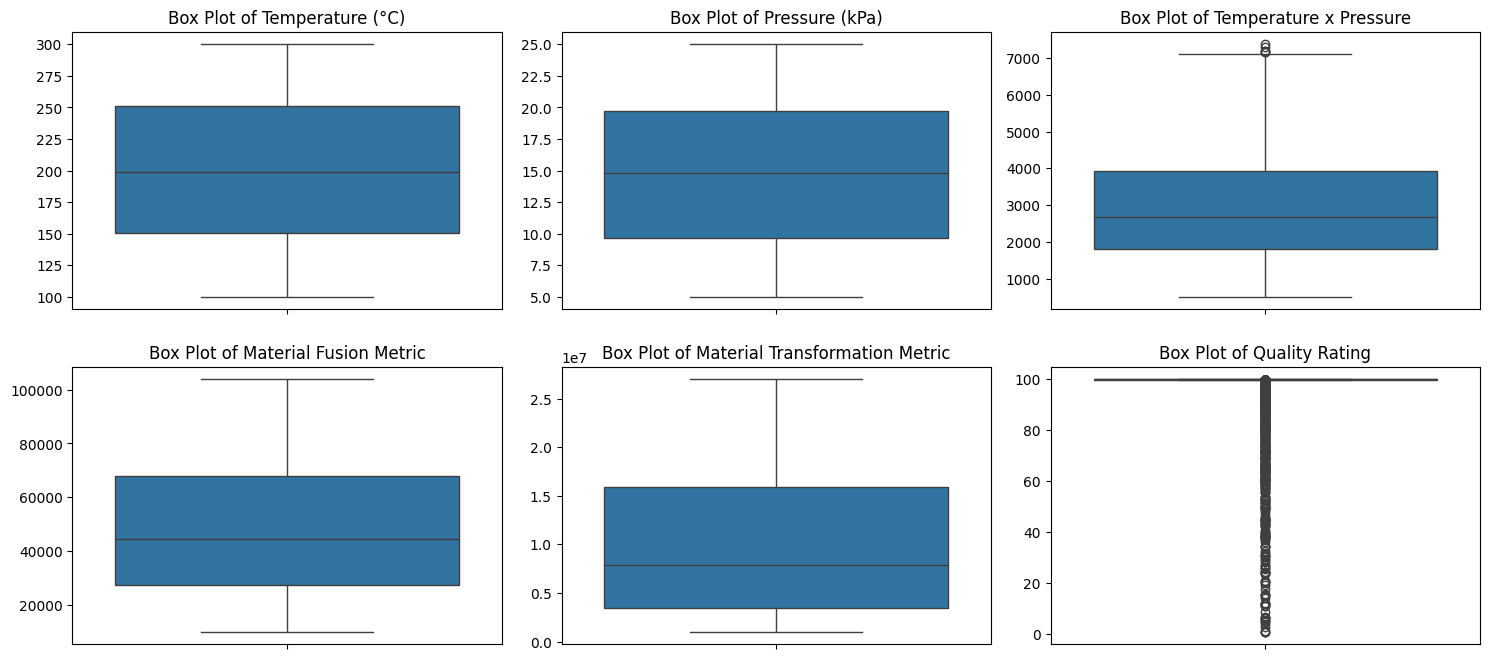

In [ ]:
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 10))
for i, column in enumerate(numerical_cols, 1):
    plt.subplot(len(numerical_cols) // 3 + 1, 3, i)
    sns.boxplot(y=df[column])
    plt.title(f'Box Plot of {column}')
    plt.ylabel('')
plt.tight_layout()
plt.show()


In [ ]:
print("Shape of DataFrame before outlier removal:", df.shape)

for column in numerical_cols:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

print("Shape of DataFrame after outlier removal:", df.shape)

Shape of DataFrame before outlier removal: (3957, 6)
Shape of DataFrame after outlier removal: (3081, 6)


In [ ]:
x=df.iloc[:,:-1]
print("Splitting of independent variable done successfully")
y=df.iloc[:,-1]
print("Splitting of dependent variable done successfully")

Splitting of independent variable done successfully
Splitting of dependent variable done successfully


In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
print("Data Splitted Successfully")

Data Splitted Successfully


In [ ]:
print(f"Number of instances for training: {len(x_train)}")
print(f"Number of instances for testing: {len(x_test)}")

Number of instances for training: 2464
Number of instances for testing: 617


In [ ]:
poly_features=PolynomialFeatures(degree=2)

In [ ]:
x_poly=poly_features.fit_transform(x)

In [ ]:
lr_model=LinearRegression()
lr_model.fit(x_poly,y)

LinearRegression()

In [ ]:
model = LinearRegression()
x_train_poly = poly_features.transform(x_train)
model.fit(x_train_poly, y_train)
print("Model Trained Successfully")

Model Trained Successfully


In [ ]:
y_pred=lr_model.predict(x_poly)
df=pd.DataFrame({'Actual':y,'Predicted':y_pred})
print(df)

          Actual   Predicted
0      99.999971  100.005966
1      99.985703   99.972722
2      99.999758  100.006449
3      99.999975  100.006215
4     100.000000   99.997139
...          ...         ...
3952  100.000000   99.997757
3953   99.999997  100.001822
3954   99.989318   99.978006
3955   99.999975  100.006228
3956  100.000000   99.995782

[3081 rows x 2 columns]


In [ ]:
# Evaluate model performance on training data using MAE, MSE, RMSE, and R2 score
y_train_pred = model.predict(x_train_poly)
mae = mean_absolute_error(y_train, y_train_pred)
mse = mean_squared_error(y_train, y_train_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_train, y_train_pred)
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root MSE (RMSE):", rmse)
print("R2 Score:", r2)

Mean Absolute Error (MAE): 0.004562940753934091
Mean Squared Error (MSE): 3.9488355024863266e-05
Root MSE (RMSE): 0.006283976052219109
R2 Score: 0.8908438893263673


In [ ]:
# Evaluate model performance on testing data using MAE, MSE, RMSE, and R2 score
x_test_poly = poly_features.transform(x_test)
y_test_pred = model.predict(x_test_poly)
mae = mean_absolute_error(y_test, y_test_pred)
mse = mean_squared_error(y_test, y_test_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_test_pred)
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root MSE (RMSE):", rmse)
print("R2 Score: ", r2)

Mean Absolute Error (MAE): 0.004400386944836958
Mean Squared Error (MSE): 3.944906693768801e-05
Root MSE (RMSE): 0.006280849221059841
R2 Score:  0.9049309075300804


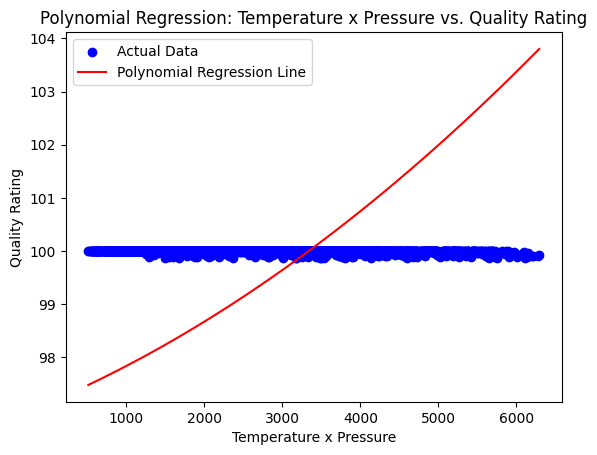

In [ ]:
temp_pressure_range = np.linspace(x['Temperature x Pressure'].min(), x['Temperature x Pressure'].max(), 100).reshape(-1, 1)

x_plot = pd.DataFrame(index=range(len(temp_pressure_range)), columns=x.columns)
x_plot['Temperature x Pressure'] = temp_pressure_range.flatten()
for col in x.columns:
    if col != 'Temperature x Pressure':
        x_plot[col] = x[col].mean()

x_plot_poly = poly_features.transform(x_plot)
y_plot_pred = model.predict(x_plot_poly)

plt.scatter(x['Temperature x Pressure'], y, color='blue', label='Actual Data')
plt.plot(x_plot['Temperature x Pressure'], y_plot_pred, color='red', label='Polynomial Regression Line')
plt.xlabel('Temperature x Pressure')
plt.ylabel('Quality Rating')
plt.title('Polynomial Regression: Temperature x Pressure vs. Quality Rating')
plt.legend()
plt.show()